In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [2]:
# first. we create a state graph object
class BMIState(TypedDict):
    weight: float
    height: float
    bmi: float
    bmi_label = str

In [3]:
#Create BMI Calculate Function

def calculate_bmi(state:BMIState) -> BMIState:
    
    weight = state['weight']
    height = state['height']
    bmi = weight / (height ** 2)
    
    state['bmi'] = round(bmi, 2)
    
    return state
    # return BMIState(weight=weight, height=height, bmi=bmi)

In [4]:
# Create a state graph

def label_bmi(state: BMIState) -> BMIState:
    bmi = state['bmi']
    
    if bmi < 18.5:
        state['bmi_label'] = 'Underweight'
    elif 18.5 <= bmi < 25:
        state['bmi_label'] = 'Normal weight'
    elif 25 <= bmi < 30:
        state['bmi_label'] = 'Overweight'
    else:
        state['bmi_label'] = 'Obesity'
    
    return state

In [5]:
#define your graph
graph = StateGraph(BMIState)

# add node, which is a function that takes the state as input and returns the new state

graph.add_node("Calculate_Bmi", calculate_bmi)
graph.add_node('Label_Bmi', label_bmi)

# add edge, which shows the transition between nodes. it takes the source node, target node, and a function that defines the transition

graph.add_edge(START, "Calculate_Bmi")
graph.add_edge('Calculate_Bmi', 'Label_Bmi')
graph.add_edge("Label_Bmi", END)


#compile the graph, which checks for any errors and prepares it for execution
workflow = graph.compile()

In [6]:
#execute the graph, which runs the graph and returns the final state

intial_state = {'weight': 70, 'height': 1.2}

final_state = workflow.invoke(intial_state)

print(final_state)

{'weight': 70, 'height': 1.2, 'bmi': 48.61}


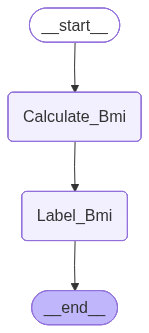

In [7]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())